# MSE StatDig : Chap 7 "Optimum filter"
## Ex 7.2 FIR Wiener Prediction
ver : DLY/19.04.2026

## General

### Description

Let's consider the linear prediction for a random process AR(1) measured with and without noise.

![filter](src/FIR-Wiener-72.png)


Let d[n] be an AR(1) process excited by a zero mean white noise with unit variance:

$$x[n] = a[1]x[n-1] + w[n]$$

The goal is to design a filter W(z) which will predict the next sample x[n+1] by observing y[n] where y[n] is the noisy version of x[n].
$$y[n] = x[n] + v[n]$$
where v[n] is a white noise disturbance with variance $\sigma^2_v$.

### Work

#### Ex1 : Signal generation

- Display the signals created by the following code :

```python
sigmaW = 1; # std of the noise process
sigmaV = 1 # std of the noise perturbation
N = 200
p = 2 #number of coefficient of the filter
worder = p-1 # filter order
a1 = 0.7
maxLag = 10
# fix the random seed for reproducibility
np.random.seed(0)
wn = sigmaW*np.random.normal(0,1,N) # noise process
vn = sigmaV*np.random.normal(0,1,N) # measurement noise
x = signal.lfilter(np.array([1]),np.array([1,-a1]),wn) #AR(1) process
x = x/np.sqrt(np.mean (x**2)) # Noramlize the power to 1
y = x+vn
```

In [76]:
import numpy as np
import matplotlib.pyplot as plt 
import sounddevice as sd
import scipy.signal as signal
import numpy.linalg as lin
import scipy.linalg as linalg
from scipy.io import wavfile
from scipy.signal import tf2zpk
from scipy.signal import freqz
from scipy.signal import TransferFunction
from scipy.linalg import toeplitz
import pywt as wt

In [77]:
sigmaW = 1; # std of the noise process
sigmaV = 1 # std of the noise perturbation
N = 200
p = 2 #number of coefficient of the filter
worder = p-1 # filter order
a1 = 0.7
maxLag = 10
# fix the random seed for reproducibility
np.random.seed(0)
wn = sigmaW*np.random.normal(0,1,N) # noise process
vn = sigmaV*np.random.normal(0,1,N) # measurement noise
x = signal.lfilter(np.array([1]),np.array([1,-a1]),wn) #AR(1) process
x = x/np.sqrt(np.mean (x**2)) # Noramlize the power to 1
y = x+vn

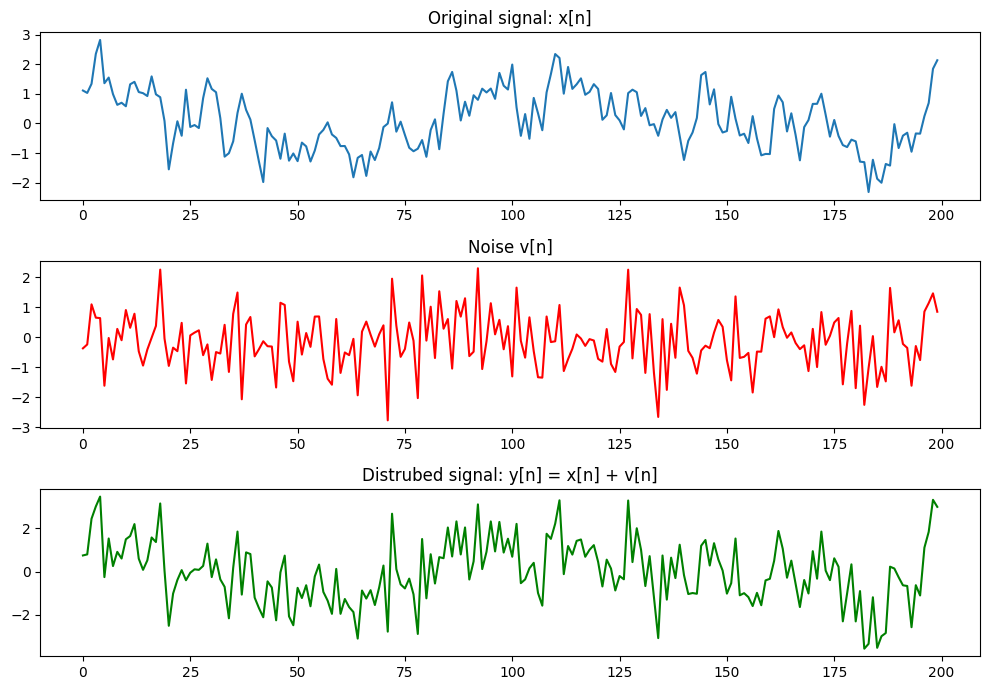

In [78]:
# Plot the signal

fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(3, 1, 1)      # initialize the top Axes
ax1.plot(x)                      # plot the top graph
plt.title('Original signal: x[n]')
fig.tight_layout()

ax2 = fig.add_subplot(3, 1, 2)      # initialize the bottom left Axes
ax2.plot(vn, c = 'r')  # plot the bottom left graph
plt.title('Noise v[n]')
fig.tight_layout()

ax3 = fig.add_subplot(3, 1, 3)      # initialize the bottom right Axes
ax3.plot(y, c = 'g')
plt.title('Distrubed signal: y[n] = x[n] + v[n]')
fig.tight_layout()

#### Ex2 : Theoretical Wiener predictor
##### Ex2.1 Design predictor

The **Wiener-Hopf** equation for the linear predictor is:

$$
R_y w = r_y(\alpha)
\Rightarrow (R_x + \sigma_v^2 I) = r_y(\alpha)
$$

As the noise is white, so the autocorrelation is null for $k \neq 0$, the autocorrelation vector $r_y(\alpha)$ is:
$$
r_y(\alpha) = r_{xx}(\alpha) + \sigma_v^2 \delta(\alpha)
$$
If $\alpha>0$ which is the case for a prediction, then the autocorrelation vector is given by:

$$r_y(\alpha) = r_{x}(\alpha)$$

So, the Wiener-Hopf equation becomes:
$$
R_y w = r_x(\alpha)
$$

The vector $r_x(\alpha)$ is the autocorrelation vector of the AR(1) process, which is given by:

$$
r_x(\alpha)= 
\begin{bmatrix}
r_{xx}[\alpha] \\
\vdots \\
r_{xx}[\alpha + p - 1] 
\end{bmatrix}
$$




So, the autocorrelation matrix is for $( p = 2 )$ and $( a[1] = 0.7 )$:

$$
R_y =
\begin{bmatrix}
r_{xx}[0] + \sigma_v^2 & r_{xx}[1] \\
r_{xx}[1] & r_{xx}[0] + \sigma_v^2
\end{bmatrix}
=
\begin{bmatrix}
1 + \sigma_v^2 & a[1] \\
a[1] & 1 + \sigma_v^2
\end{bmatrix}
=
\begin{bmatrix}
1 + \sigma_v^2 & 0.7 \\
0.7 & 1 + \sigma_v^2
\end{bmatrix}
$$

And the shifted autocorrelation vector for a one-step prediction $( \alpha = 1 )$:

$$
r_x(\alpha) =
\begin{bmatrix}
r_{xx}[\alpha] \\
r_{xx}[\alpha + 1]
\end{bmatrix}
=
\begin{bmatrix}
r_{xx}[1] \\
r_{xx}[2]
\end{bmatrix}
=
\begin{bmatrix}
a[1] \\
(a[1])^2
\end{bmatrix}
=
\begin{bmatrix}
0.7 \\
0.49
\end{bmatrix}
$$


Finally, the solution of the **Wiener-Hopf** is:

$$
w =
\begin{bmatrix}
1 + \sigma_v^2 & a[1] \\
a[1] & 1 + \sigma_v^2
\end{bmatrix}
^{-1}
\cdot
\begin{bmatrix}
a[1] \\
(a[1])^2
\end{bmatrix}
=
\begin{bmatrix}
1 + \sigma_v^2 & 0.7 \\
0.7 & 1 + \sigma_v^2
\end{bmatrix}^{-1}
\begin{bmatrix}
0.7 \\
0.49
\end{bmatrix}=
\begin{bmatrix}
0.3114 \\
0.1796
\end{bmatrix}
$$


If the noise is null $( \sigma_v^2 = 0 )$, then the coefficients become:

$$
w =
\begin{bmatrix}
1 & a[1] \\
a[1] & 1
\end{bmatrix}^{-1}
\cdot
\begin{bmatrix}
a[1] \\
(a[1])^2
\end{bmatrix}
=
\begin{bmatrix}
1 & 0.7 \\
0.7 & 1
\end{bmatrix}^{-1}
\begin{bmatrix}
0.7 \\
0.49
\end{bmatrix}
=
\begin{bmatrix}
a[1] \\
(a[1])^2
\end{bmatrix}
=
\begin{bmatrix}
0.7 \\
0
\end{bmatrix}
$$

The solution is logical. As there isn’t any noise, the best coefficient to predict the next sample is the coefficient of the AR process itself:

$$
x[n + 1] = a[1] \cdot x[n]
$$

Your work:

- Compute the theoretical predictor by implementing a function `wiener_predict_theo()`:

```python
def wiener_predict_theo(sigmav,a1,order,step):
    # computes the theoretical Wiener FIR predictor for an AR(1) process disturbed 
    # by a random noise described by sigmav
    # Input : 
    # - sigmav : (scalar) standrad deviation of the noise
    # - a      : (scalar) coefficient of the AR(1)
    # - order  : (scalar) order of the Wiener FIR filter (order = p-1 => p = order + 1)
    # - step   : (scalar) step of prediction
    # Output : 
    # - w    : (p,) coefficient of the Wiener FIR predictor

    # -- your code --

    return w

In [79]:
def wiener_predict_theo(sigmaV,a,order,step):
    # computes the theoretical Wiener FIR predictor for an AR(1) process disturbed 
    # by a random noise described by sigmav
    # Input : 
    # - sigmav : (scalar) standrad deviation of the noise
    # - a      : (scalar) coefficient of the AR(1)
    # - order  : (scalar) order of the Wiener FIR filter (order = p-1 => p = order + 1)
    # - step   : (scalar) step of prediction
    # Output : 
    # - w    : (p,) coefficient of the Wiener FIR predictor
    p = order + 1
    lags = np.arange(p)
    rx = a ** lags
    Rx = toeplitz(rx)
    Ry = Rx + (sigmaV**2) * np.eye(p)
    lags_prediction = step + np.arange(p)
    r_x_alpha = a ** lags_prediction
    w = np.linalg.solve(Ry, r_x_alpha)

    return w

In [80]:
print(wiener_predict_theo(sigmaV, a1, worder, 1))

[0.3011396  0.13960114]


#### Ex2 : Estimated Wiener filter predictor

##### Ex2.1 : Estimated autocorrelation
Unfortunately, in most of the application, the autocorrelation must be estimated.
$$
r_{y}[k] = \frac{1}{N} \sum_{n=0}^{N-1-k} y[n] y[n+k]
$$

- Display the estimated autocorrelation $r_y[k]$ and compare it to the theoretical one.

In [81]:
rd_est = np.correlate(y, y, mode='full') / len(y)
lags = np.arange(-20, 21)

rd_k = a1 ** abs(lags)
rd_k[20] = rd_k[20] + sigmaV**2 

center = len(y) - 1
rd_est = rd_est[center-20 : center+21]

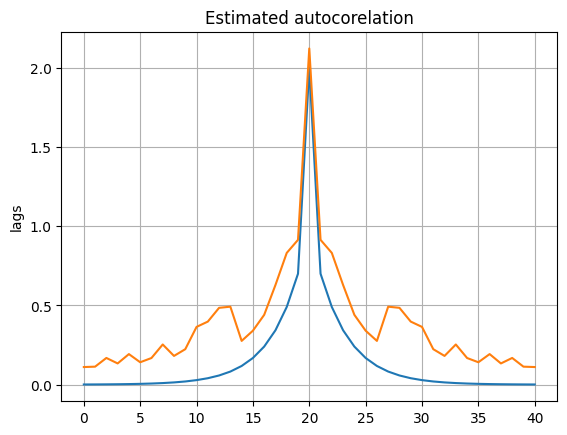

In [82]:
plt.figure()
plt.plot(rd_k)
plt.plot(rd_est)
plt.title('Estimated autocorelation')
plt.ylabel('lags')
plt.grid()
plt.show()

##### Ex2.2 : Design filter predictor
By using the estimated autocorrelation, the Wiener filter coefficient can be estimated.
The results shows very close results with the theoretical coefficient because the estimator of the autocorrelation is good for small order (order=p-1).
The wiener predictor is given by:
$$
w = R_y^{-1} r_{y}(\alpha)$$

Where $R_y$ is the autocorrelation matrix and $r_{y}(\alpha)$ is the shifted autocorrelation vector.
The autocorrelation matrix is given by:
$$
R_y =
\begin{bmatrix}
r_{yy}[0] & r_{yy}[1] \\
r_{yy}[1] & r_{yy}[0]
\end{bmatrix}
$$

And the shifted autocorrelation vector for a one-step prediction $( \alpha = 1 )$:
$$
r_y(\alpha) =
\begin{bmatrix}
r_{yy}[\alpha] \\
r_{yy}[\alpha + 1]
\end{bmatrix}
$$
And the mean square error (MSE) is given by:
$$
\xi_{\text{min}} = r_{yy}[0] - w^T r_y(\alpha)
$$

Unfortunatley, the mean square error is including the noise variance $\sigma_v^2$ = 1 because $r_{yy}[0]=r_{xx}[0]+r_{vv}[0]$. So the MSE estimated is higher than the theoretical one which was using $r_{xx}[0]$. If you want to remove the noise variance $r_{vv}[0] = \sigma_v^2$, you can use the following formula:
$$
\xi_{\text{min,x}} = \xi_{\text{min}} - \sigma_v^2$$


Your work:

- Compute the theoretical predictor by implementing a function `wiener_predict()`:

```python
def wiener_predict(y,order,step):
    # computes the estimated Wiener FIR predictor for an AR(1) process disturbed 
    # by a random noise described by sigmav
    # Input : 
    # - y      : (N,) noisy signal to be predicted
    # - order  : (scalar) order of the Wiener FIR filter (order = p-1 => p = order + 1)
    # - step   : (scalar) step of prediction (alpha)
    # Output : 
    # - w      : (p,) coefficients of the Wiener FIR predictor
    # - E      : (scalar) MSE of the predictor
    # -- your code --

    return w, E
```

In [83]:
def wiener_predict(y,order,step):
    # computes the estimated Wiener FIR predictor for an AR(1) process disturbed 
    # by a random noise described by sigmav
    # Input : 
    # - y      : (N,) noisy signal to be predicted
    # - order  : (scalar) order of the Wiener FIR filter (order = p-1 => p = order + 1)
    # - step   : (scalar) step of prediction (alpha)
    # Output : 
    # - w      : (p,) coefficients of the Wiener FIR predictor
    # - E      : (scalar) MSE of the predictor
    # -- your code --
    p = order + 1
    N = len(y)
    mid = N - 1

    # autocorrelation
    ryy_k = np.correlate(y, y, mode='full') / N
    Ry = toeplitz(ryy_k[mid : mid +p])

    ry_alpha = ryy_k[mid + step : mid + step + p]
    w = np.linalg.solve(Ry, ry_alpha)
    E = ryy_k[mid] - np.dot(w, ry_alpha)


    return w, E

In [84]:
w_est, E_est = wiener_predict(y, worder, 1)
print("Coefficients calculés :", w_est)
print("Erreur MSE calculée :", E_est)

Coefficients calculés : [0.32161912 0.25323633]
Erreur MSE calculée : 1.6176621162430596


##### Ex2.3 : Prediction
The prediction is given by the following formula:
$$
\hat{x}[n + 1] = w^T y[n]$$

This can be simply realized by the filter function from scipy `xhat = filter(w,1,y)`.

As the output is the prediction, we can compare the prediction to the original signal x[n] by computing the error and the corresponding MSE
$$
e[n] = x[n + 1] - \hat{x}[n + 1]
$$

$$
mse = \frac{1}{N} \sum_{n=0}^{N-1} e[n]^2
$$

your work :
- compute and display the prediction, the error and the MSE


In [85]:
x_hat = signal.lfilter(w_est, 1, y)
error = x[1:] - x_hat[:-1]

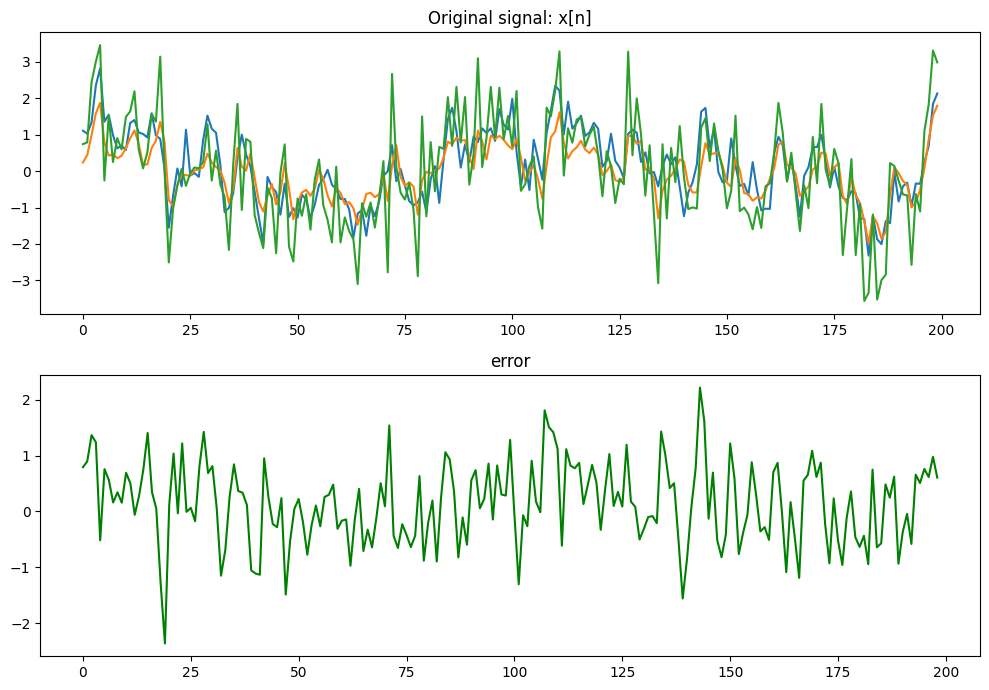

In [86]:
# Plot the signal

fig = plt.figure(figsize=(10, 7))

ax1 = fig.add_subplot(2, 1, 1)      # initialize the top Axes
ax1.plot(x)
ax1.plot(x_hat)
ax1.plot(y)  
plt.title('Original signal: x[n]')
fig.tight_layout()

ax2 = fig.add_subplot(2, 1, 2)      # initialize the bottom left Axes
ax2.plot(error, c = 'g')  # plot the bottom left graph
plt.title('error')
fig.tight_layout()